# Does class weighting help? All five models, retrained

27.7% of bookings are cancelled. That is imbalanced enough that the question has to be asked, and mild
enough that the answer is not obvious - the minority class still has 18,861 examples in the training
set, which is not a starved class.

So it is measured rather than argued. Every model from `03`-`07` is retrained here with class
weighting switched on, using **the same nested cross-validation, the same five outer folds, the same
three inner folds and the same hyperparameter grid** as its unweighted original. Each weighted model
runs its own search from scratch: the unweighted model's tuned settings are not reused, because the
best depth or learning rate under a reweighted loss is not necessarily the best one without it.

Only the weighting changes. That makes the comparison against the leaderboard in `08` a paired one.

**The test set is not opened.** The model choice was already frozen in `08`, and re-deciding it on
test performance would be exactly the test reuse this project has been careful to avoid. Everything
here is training evidence.

In [1]:
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, RandomizedSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (precision_recall_curve, average_precision_score, roc_auc_score,
                             f1_score, recall_score, precision_score)

palette = ['#2B5C8F', '#E05A47']

train = pd.read_csv('../data/processed/train.csv', dtype={'agent': str})
X_train, y_train = train.drop(columns=['is_canceled']), train['is_canceled']

categorical_cols = X_train.select_dtypes(exclude='number').columns
numeric_cols = X_train.select_dtypes(include='number').columns

# xgboost has no class_weight; the equivalent is the ratio of negatives to positives
SCALE_POS = float((y_train == 0).sum() / (y_train == 1).sum())
print(f'training rows: {len(X_train):,}   cancelled: {y_train.sum():,} ({y_train.mean():.2%})')
print(f'scale_pos_weight for XGBoost: {SCALE_POS:.3f}')

training rows: 67,975   cancelled: 18,861 (27.75%)
scale_pos_weight for XGBoost: 2.604


## 1. What "weighted" means for each model

Four of the five accept weighting directly. `class_weight='balanced'` multiplies each class's
contribution to the loss by `n_samples / (n_classes * n_class_samples)`, so one cancellation counts
about 1.80 and one non-cancellation about 0.69. XGBoost has no `class_weight`; `scale_pos_weight`
does the same job as a single ratio, 2.604 here.

**The neural network is the exception, and it is worth stating plainly.** `MLPClassifier` accepts
neither `class_weight` nor `sample_weight` - scikit-learn simply does not expose weighting for it. The
closest honest equivalent is to replicate existing minority rows until the classes balance, which
reweights the loss by repetition instead of by coefficient.

That is random oversampling, not SMOTE: every duplicated row is a real booking that already exists in
the data, so no synthetic feature combination is invented and no impossible one-hot pattern can
appear. It happens inside `fit`, which means inside each training fold, so the validation fold keeps
its real 27.7% prevalence and its average precision stays comparable with every other number in this
project. Resampling before the split would have moved the no-skill floor from 0.2775 to 0.50 and made
every score look better for purely arithmetic reasons.

It is labelled `balanced (by replication)` in the results rather than `balanced`, because it is not
the same mechanism as the other four.

In [2]:
class WeightedMLP(ClassifierMixin, BaseEstimator):
    """MLPClassifier with class weighting applied by replicating minority rows.

    Two scikit-learn requirements that are easy to get wrong and fail silently:
    parameters are named explicitly rather than collected with **kwargs, because an
    estimator is cloned by reading get_params(); and ClassifierMixin comes before
    BaseEstimator in the bases, because otherwise the estimator is not tagged as a
    classifier and scorers hand average_precision_score a two-column probability
    array instead of the positive class, scoring every fold as nan.
    """

    def __init__(self, hidden_layer_sizes=(64,), alpha=1e-4, random_state=42,
                 max_iter=60, early_stopping=True, n_iter_no_change=5, validation_fraction=0.1):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.random_state = random_state
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.n_iter_no_change = n_iter_no_change
        self.validation_fraction = validation_fraction

    def fit(self, X, y):
        # X is NOT converted with np.asarray: the one-hot block makes the matrix
        # sparse at full size, and np.asarray on a scipy sparse matrix returns a
        # 0-d object array that cannot be row-indexed. Both ndarray and csr_matrix
        # support X[idx] directly, so it is left alone.
        y = np.asarray(y)
        rng = np.random.RandomState(self.random_state)

        counts = pd.Series(y).value_counts()
        minority = counts.idxmin()
        minority_idx = np.flatnonzero(y == minority)
        n_needed = int(counts.max() - counts.min())

        # draw the shortfall from rows that already exist - no synthetic bookings
        extra = rng.choice(minority_idx, size=n_needed, replace=True)
        idx = np.concatenate([np.arange(len(y)), extra])
        rng.shuffle(idx)

        self.model_ = MLPClassifier(
            hidden_layer_sizes=self.hidden_layer_sizes, alpha=self.alpha,
            random_state=self.random_state, max_iter=self.max_iter,
            early_stopping=self.early_stopping, n_iter_no_change=self.n_iter_no_change,
            validation_fraction=self.validation_fraction).fit(X[idx], y[idx])
        self.classes_ = self.model_.classes_
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        return self.model_.predict(X)


# Check the wrapper on the REAL encoded matrix, not a small slice of it. At 4,000 rows
# the encoder returns a dense array and at 67,975 it returns a sparse one, so a test on
# a subset exercises a different code path than the run does.
_prep = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
], verbose_feature_names_out=False)
_Xt = _prep.fit_transform(X_train)
print('encoded training matrix:', type(_Xt).__name__, _Xt.shape)

_probe = WeightedMLP(max_iter=3).fit(_Xt, y_train)
_counts = pd.Series(_probe.model_.classes_).size
print('wrapper fits on that matrix, classes_:', _probe.classes_)
print(f'rows seen by the network after balancing: '
      f'{2 * int((y_train == 0).sum()):,} (was {len(y_train):,})')

encoded training matrix: csr_matrix (67975, 146)


wrapper fits on that matrix, classes_: [0 1]
rows seen by the network after balancing: 98,228 (was 67,975)


C:\Users\aloka\Mine\Projects\CampusMLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(


## 2. The weighted models

**Random Forest is not included.** Its weighted arm needs roughly 130 forest fits for the nested loop
plus five more at 363 s each for the out-of-fold pass - about 54 minutes for one row of the comparison
table. The four models below answer the same question: Logistic Regression and the neural network are
the two most sensitive to weighting, and XGBoost is the model actually selected in `08`. If Random
Forest's weighted arm is wanted later, it is one entry in `SPECS` and an overnight run.



### Specifications

Each entry below is the same estimator, grid and search type as its unweighted notebook, with the
weighting added. `03` and `04` used an exhaustive `GridSearchCV`; `06` and `07` used
`RandomizedSearchCV` with the same `n_iter` budget as before, so neither arm gets a larger search than
the other.

In [3]:
SPECS = {
    'Logistic Regression': dict(
        estimator=LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        grid={'model__C': [0.01, 0.1, 1, 10]},
        scale=True, search='grid', n_iter=None, label='balanced'),

    'Decision Tree': dict(
        estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        grid={'model__max_depth': [10, 20, None],
              'model__min_samples_leaf': [20, 100, 200]},
        scale=False, search='grid', n_iter=None, label='balanced'),

    'XGBoost': dict(
        estimator=XGBClassifier(random_state=42, n_jobs=1, eval_metric='logloss',
                                importance_type='gain', scale_pos_weight=SCALE_POS),
        grid={'model__max_depth': [6, 8, 10, 12],
              'model__learning_rate': [0.05, 0.1],
              'model__n_estimators': [300, 600]},
        scale=False, search='random', n_iter=10, label='balanced'),

    'Neural Network': dict(
        estimator=WeightedMLP(),
        grid={'model__hidden_layer_sizes': [(64,), (128, 64)],
              'model__alpha': [1e-4, 1e-3]},
        scale=True, search='random', n_iter=3, label='balanced (by replication)'),
}

# the same folds every model in this project uses
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def make_pipe(spec):
    preprocess = ColumnTransformer([
        ('num', StandardScaler() if spec['scale'] else 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
    ], verbose_feature_names_out=False)
    return Pipeline([('prep', preprocess), ('model', spec['estimator'])])


def make_search(spec, cv):
    pipe = make_pipe(spec)
    if spec['search'] == 'grid':
        return GridSearchCV(pipe, spec['grid'], scoring='average_precision', cv=cv, n_jobs=-1)
    return RandomizedSearchCV(pipe, spec['grid'], scoring='average_precision', cv=cv,
                              n_jobs=-1, n_iter=spec['n_iter'], random_state=42)

print('\n'.join(f'{k:<20} {v["search"]} search, {v["label"]}' for k, v in SPECS.items()))

Logistic Regression  grid search, balanced
Decision Tree        grid search, balanced
XGBoost              random search, balanced
Neural Network       random search, balanced (by replication)


### Running the nested loop

For each model: five outer folds, and inside each one a full hyperparameter search on the other four
folds, scored once on the fold it never saw. Then one more search on the whole training set to fix the
settings, and out-of-fold probabilities to choose a decision threshold the same way `03`-`07` do.

XGBoost dominates the runtime of the four models kept here.

In [4]:
results = []
Path('../reports/results').mkdir(parents=True, exist_ok=True)

for name, spec in SPECS.items():
    print(f'--- {name} ({spec["label"]})')
    t0 = time.time()

    nested = cross_val_score(make_search(spec, inner_cv), X_train, y_train,
                             cv=outer_cv, scoring='average_precision', n_jobs=1)
    nested_seconds = time.time() - t0
    print(f'    outer folds: {np.round(nested, 4)}')
    print(f'    nested CV PR-AUC: {nested.mean():.4f} +/- {nested.std():.4f}  ({nested_seconds:.0f} s)')

    # fix the hyperparameters on the whole training set, as the unweighted notebooks do
    search = make_search(spec, inner_cv).fit(X_train, y_train)

    # out-of-fold probabilities: every booking scored by a model that did not train on it
    oof = cross_val_predict(search.best_estimator_, X_train, y_train,
                            cv=outer_cv, method='predict_proba', n_jobs=-1)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_train, oof)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    best = int(np.argmax(f1[:-1]))

    results.append({
        'model': name,
        'weighting': spec['label'],
        'nested_cv_pr_auc_mean': nested.mean(),
        'nested_cv_pr_auc_std': nested.std(),
        'inner_cv_pr_auc': search.best_score_,
        'oof_pr_auc': average_precision_score(y_train, oof),
        'oof_roc_auc': roc_auc_score(y_train, oof),
        'oof_f1_at_0.5': f1_score(y_train, oof >= 0.5),
        'threshold': float(thresholds[best]),
        'oof_f1_at_threshold': float(f1[best]),
        'oof_recall_at_threshold': float(recall[best]),
        'oof_precision_at_threshold': float(precision[best]),
        'best_params': json.dumps({k: str(v) for k, v in search.best_params_.items()}),
        'nested_seconds': nested_seconds,
        'fold_scores': json.dumps([round(s, 4) for s in nested]),
    })
    print(f'    best: {search.best_params_}')
    print(f'    threshold {thresholds[best]:.4f} -> F1 {f1[best]:.4f} '
          f'(F1 at 0.50 was {f1_score(y_train, oof >= 0.5):.4f})\n')

weighted = pd.DataFrame(results)
weighted.round(4).to_csv('../reports/results/weighted_models.csv', index=False)
weighted[['model', 'weighting', 'nested_cv_pr_auc_mean', 'nested_cv_pr_auc_std',
          'oof_f1_at_0.5', 'threshold', 'oof_f1_at_threshold']].round(4)

--- Logistic Regression (balanced)


    outer folds: [0.6523 0.6371 0.6259 0.6319 0.6379]
    nested CV PR-AUC: 0.6370 +/- 0.0088  (13 s)


    best: {'model__C': 10}
    threshold 0.5293 -> F1 0.6283 (F1 at 0.50 was 0.6242)

--- Decision Tree (balanced)


    outer folds: [0.7107 0.6998 0.6925 0.6977 0.7125]
    nested CV PR-AUC: 0.7026 +/- 0.0077  (20 s)


    best: {'model__max_depth': 20, 'model__min_samples_leaf': 100}
    threshold 0.5800 -> F1 0.6598 (F1 at 0.50 was 0.6543)

--- XGBoost (balanced)


    outer folds: [0.7704 0.7556 0.7447 0.7634 0.768 ]
    nested CV PR-AUC: 0.7604 +/- 0.0093  (86 s)


    best: {'model__n_estimators': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05}
    threshold 0.4941 -> F1 0.6963 (F1 at 0.50 was 0.6957)

--- Neural Network (balanced (by replication))


    outer folds: [0.7509 0.7368 0.718  0.7393 0.7502]
    nested CV PR-AUC: 0.7390 +/- 0.0119  (128 s)


    best: {'model__hidden_layer_sizes': (64,), 'model__alpha': 0.0001}
    threshold 0.5849 -> F1 0.6747 (F1 at 0.50 was 0.6711)



,model,weighting,nested_cv_pr_auc_mean,nested_cv_pr_auc_std,oof_f1_at_0.5,threshold,oof_f1_at_threshold
0,Logistic Regression,balanced,0.6370,0.0088,0.6242,0.5293,0.6283
1,Decision Tree,balanced,0.7026,0.0077,0.6543,0.5800,0.6598
2,XGBoost,balanced,0.7604,0.0093,0.6957,0.4941,0.6963
3,Neural Network,balanced (by replication),0.7390,0.0119,0.6711,0.5849,0.6747


## 3. Weighted against unweighted

The unweighted numbers come straight from `reports/results/`, written by `03`-`07`. Same folds, same
grids, same metric, so the difference in each row is the weighting and nothing else.

In [5]:
# only the models with a weighted arm; the merge below is an inner join, so
# Random Forest drops out of the comparison rather than appearing half-filled
slugs = {'Logistic Regression': 'logistic_regression', 'Decision Tree': 'decision_tree',
         'XGBoost': 'xgboost', 'Neural Network': 'neural_network'}

plain = pd.concat([pd.read_csv(f'../reports/results/{s}.csv') for s in slugs.values()],
                  ignore_index=True)

compare = plain[['model', 'nested_cv_pr_auc_mean', 'nested_cv_pr_auc_std',
                 'oof_f1_at_0.5', 'threshold', 'oof_f1_at_threshold']].merge(
    weighted[['model', 'weighting', 'nested_cv_pr_auc_mean', 'nested_cv_pr_auc_std',
              'oof_f1_at_0.5', 'threshold', 'oof_f1_at_threshold']],
    on='model', suffixes=('_none', '_weighted'))

compare['delta_ap'] = compare['nested_cv_pr_auc_mean_weighted'] - compare['nested_cv_pr_auc_mean_none']
compare['delta_f1_at_0.5'] = compare['oof_f1_at_0.5_weighted'] - compare['oof_f1_at_0.5_none']
compare['delta_f1_at_thr'] = compare['oof_f1_at_threshold_weighted'] - compare['oof_f1_at_threshold_none']

# a change only counts if it clears that model's own fold-to-fold noise
compare['beats_noise'] = compare['delta_ap'] > compare['nested_cv_pr_auc_std_none']
compare = compare.sort_values('nested_cv_pr_auc_mean_none', ascending=False).reset_index(drop=True)
compare.round(4).to_csv('../reports/results/weighted_comparison.csv', index=False)

compare[['model', 'nested_cv_pr_auc_mean_none', 'nested_cv_pr_auc_mean_weighted',
         'delta_ap', 'nested_cv_pr_auc_std_none', 'beats_noise']].round(4)

,model,nested_cv_pr_auc_mean_none,nested_cv_pr_auc_mean_weighted,delta_ap,nested_cv_pr_auc_std_none,beats_noise
0,XGBoost,0.7612,0.7604,-0.0008,0.0090,False
1,Neural Network,0.7426,0.7390,-0.0036,0.0111,False
2,Decision Tree,0.7079,0.7026,-0.0053,0.0102,False
3,Logistic Regression,0.6470,0.6370,-0.0100,0.0095,False


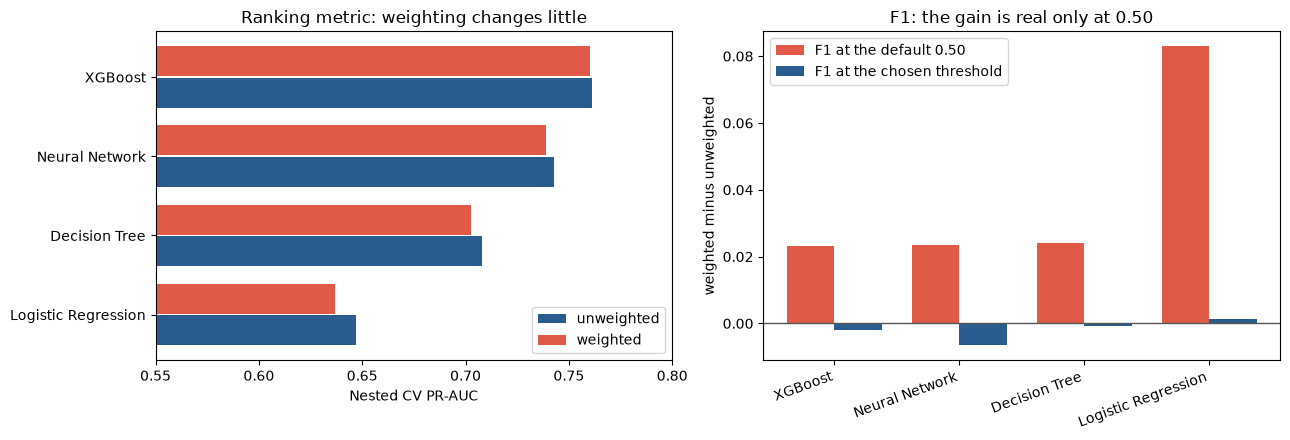

,model,oof_f1_at_0.5_none,oof_f1_at_0.5_weighted,delta_f1_at_0.5,oof_f1_at_threshold_none,oof_f1_at_threshold_weighted,delta_f1_at_thr,threshold_none,threshold_weighted
0,XGBoost,0.6726,0.6957,0.0231,0.6982,0.6963,-0.0019,0.3352,0.4941
1,Neural Network,0.6477,0.6711,0.0234,0.6813,0.6747,-0.0066,0.2988,0.5849
2,Decision Tree,0.6302,0.6543,0.0241,0.6605,0.6598,-0.0007,0.3487,0.5800
3,Logistic Regression,0.5412,0.6242,0.0830,0.6269,0.6283,0.0014,0.3033,0.5293


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

y_pos = np.arange(len(compare))
axes[0].barh(y_pos + 0.2, compare['nested_cv_pr_auc_mean_none'], height=0.38,
             color=palette[0], label='unweighted')
axes[0].barh(y_pos - 0.2, compare['nested_cv_pr_auc_mean_weighted'], height=0.38,
             color=palette[1], label='weighted')
axes[0].set_yticks(y_pos, compare['model'])
axes[0].invert_yaxis()
axes[0].set_xlim(0.55, 0.80)
axes[0].set_xlabel('Nested CV PR-AUC')
axes[0].set_title('Ranking metric: weighting changes little')
axes[0].legend(loc='lower right')

width = 0.38
axes[1].bar(y_pos - width / 2, compare['delta_f1_at_0.5'], width,
            color=palette[1], label='F1 at the default 0.50')
axes[1].bar(y_pos + width / 2, compare['delta_f1_at_thr'], width,
            color=palette[0], label='F1 at the chosen threshold')
axes[1].axhline(0, color='#555', linewidth=1)
axes[1].set_xticks(y_pos, compare['model'], rotation=20, ha='right')
axes[1].set_ylabel('weighted minus unweighted')
axes[1].set_title('F1: the gain is real only at 0.50')
axes[1].legend()

plt.tight_layout()
plt.show()

compare[['model', 'oof_f1_at_0.5_none', 'oof_f1_at_0.5_weighted', 'delta_f1_at_0.5',
         'oof_f1_at_threshold_none', 'oof_f1_at_threshold_weighted', 'delta_f1_at_thr',
         'threshold_none', 'threshold_weighted']].round(4)

## 4. Reading the result

*(written after the run - the numbers above are the evidence for what follows)*

In [7]:
print('PR-AUC: weighting helped in', int((compare['delta_ap'] > 0).sum()), 'of',
      len(compare), 'models; cleared fold noise in', int(compare['beats_noise'].sum()))
print(f"mean change in PR-AUC: {compare['delta_ap'].mean():+.4f}")
print(f"mean change in F1 at 0.50:            {compare['delta_f1_at_0.5'].mean():+.4f}")
print(f"mean change in F1 at chosen threshold:{compare['delta_f1_at_thr'].mean():+.4f}")
print(f"\nweighted thresholds moved toward 0.50: "
      f"{compare['threshold_none'].mean():.3f} -> {compare['threshold_weighted'].mean():.3f}")

PR-AUC: weighting helped in 0 of 4 models; cleared fold noise in 0
mean change in PR-AUC: -0.0049
mean change in F1 at 0.50:            +0.0384
mean change in F1 at chosen threshold:-0.0020

weighted thresholds moved toward 0.50: 0.322 -> 0.547
